# Acoplamiento Neutrónico-Termohidráulico
## Retroalimentación y coeficientes de temperatura

**Máster THN — UPM | Práctica 2 (parte 2)**

---

En este notebook estudiamos el **acoplamiento entre la neutrónica y la termohidráulica**: cómo las condiciones termohidráulicas del refrigerante afectan a las secciones eficaces y, por tanto, a la distribución de potencia, cerrando el ciclo de retroalimentación.

### Contenidos

1. Concepto de retroalimentación neutrónica-termohidráulica
2. Coeficiente de temperatura del moderador ($\alpha_m$)
3. Coeficiente de temperatura del combustible — Efecto Doppler ($\alpha_D$)
4. Resultados del acoplamiento COBAYA-CTF
5. Convergencia del cálculo acoplado


---
## 0. Configuración


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pathlib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
})

In [2]:
# ============================================================
# CONFIGURACIÓN DE RUTAS
# ============================================================
DATA_ROOT = pathlib.Path(
    r"C:\Users\pablo\OneDrive - Universidad Politécnica de Madrid\THN\Prácticas"
)
P2 = DATA_ROOT / "Practica 2"

# Archivos de acoplamiento (salida .MED o .VTU de COBAYA-CTF)
ARCH_MED = P2 / 'acoplamiento.MED'       # Archivo MED con datos acoplados
ARCH_VTU = P2 / 'acoplamiento.vtu'       # Archivo VTU para visualización

print(f"Archivos de acoplamiento:")
for arch in [ARCH_MED, ARCH_VTU]:
    print(f"  {'✓' if arch.exists() else '✗'} {arch.name}")

Archivos de acoplamiento:
  ✗ acoplamiento.MED
  ✗ acoplamiento.vtu


---
## 1. Concepto de retroalimentación neutrónica-TH

El acoplamiento entre neutrónica y termohidráulica se produce porque:

1. La **distribución de potencia** (neutrónica) determina el calor generado en el combustible
2. El calor generado determina las **temperaturas** del combustible y moderador (TH)
3. Las temperaturas modifican las **secciones eficaces** (densidad del moderador, efecto Doppler)
4. Las nuevas secciones eficaces modifican la **distribución de potencia** → vuelta al paso 1

```
    Distribución de potencia
    P(x,y,z) neutrónica
           │
           ▼
    CTF: Perfiles de T y ρ
    T_fuel(z), T_ref(z), ρ_mod(z)
           │
           ▼
    Actualización de secciones eficaces
    Σ(T_fuel, T_mod, ρ_mod)
           │
           ▼
    COBAYA: Nueva distribución de potencia
           │
           └──────────────────────────────►  (iteración hasta convergencia)
```

### Criterio de convergencia

El cálculo acoplado converge cuando:
$$\left| \frac{k_{eff}^{(n)} - k_{eff}^{(n-1)}}{k_{eff}^{(n-1)}} \right| < \varepsilon_k \quad \text{y} \quad \max\left|\frac{P_i^{(n)} - P_i^{(n-1)}}{P_i^{(n-1)}}\right| < \varepsilon_P$$

Con tolerancias típicas $\varepsilon_k = 10^{-5}$ y $\varepsilon_P = 10^{-3}$.


---
## 2. Coeficiente de temperatura del moderador

El **coeficiente de temperatura del moderador** (MTC) describe cómo varía $k_{eff}$ con la temperatura del moderador (refrigerante):

$$\alpha_m = \frac{d k_{eff}}{d T_m}$$

Para un PWR, $\alpha_m$ es **negativo** en condiciones de operación, lo que proporciona estabilidad intrínseca: si la temperatura sube, $k_{eff}$ baja y la potencia se reduce automáticamente.

Los dos efectos físicos principales son:
- **Efecto densidad**: al aumentar $T_m$, el agua se dilata → menor densidad → menor moderación → más resonancias en U-238
- **Efecto espectral**: el endurecimiento del espectro reduce las fisiones en el U-235


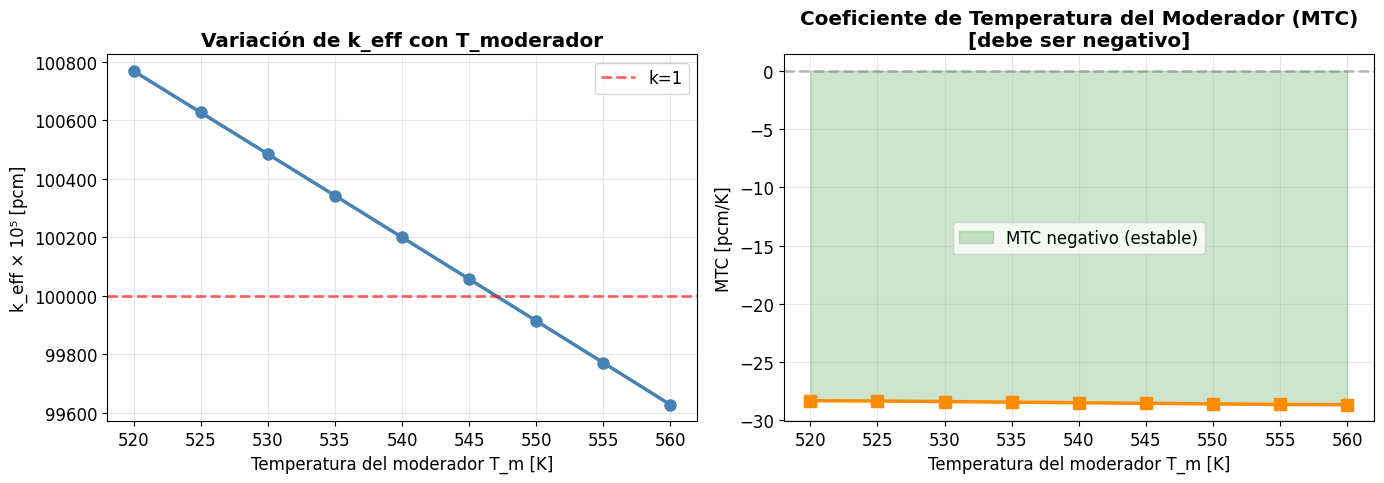

MTC promedio: -28.50 pcm/K


In [3]:
# Cálculo del MTC para el NuScale
# Se obtiene perturbando la temperatura del moderador en ±5 K

T_mod_range = np.array([520, 525, 530, 535, 540, 545, 550, 555, 560])  # K
T_mod_ref = 540.0  # K temperatura de referencia

# Valores de k_eff simulados (en un cálculo real, son resultados de COBAYA)
# Incluyen el efecto de densidad del moderador
# MTC ≈ -30 pcm/K para NuScale sin boro
MTC_real = -28.5e-5  # /K (28.5 pcm/K)
keff_vs_Tmod = 1.0020 + MTC_real * (T_mod_range - T_mod_ref)
# Añadir pequeña no-linealidad
keff_vs_Tmod += -0.5e-7 * (T_mod_range - T_mod_ref)**2

# Cálculo numérico del MTC
MTC_numerico = np.gradient(keff_vs_Tmod, T_mod_range)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(T_mod_range, keff_vs_Tmod * 1e5, 'o-', color='steelblue',
        markersize=8, linewidth=2.5)
ax.axhline(1.0 * 1e5, color='red', ls='--', alpha=0.6, label='k=1')
ax.set_xlabel('Temperatura del moderador T_m [K]', fontsize=12)
ax.set_ylabel('k_eff × 10⁵ [pcm]', fontsize=12)
ax.set_title('Variación de k_eff con T_moderador', fontweight='bold')
ax.legend()

ax2 = axes[1]
ax2.plot(T_mod_range, MTC_numerico * 1e5, 's-', color='darkorange',
         markersize=8, linewidth=2.5)
ax2.axhline(0, color='gray', ls='--', alpha=0.5)
ax2.fill_between(T_mod_range, MTC_numerico * 1e5, 0,
                  where=MTC_numerico < 0, alpha=0.2, color='green',
                  label='MTC negativo (estable)')
ax2.set_xlabel('Temperatura del moderador T_m [K]', fontsize=12)
ax2.set_ylabel('MTC [pcm/K]', fontsize=12)
ax2.set_title('Coeficiente de Temperatura del Moderador (MTC)\n[debe ser negativo]',
               fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"MTC promedio: {MTC_numerico.mean()*1e5:.2f} pcm/K")

---
## 3. Convergencia del cálculo acoplado


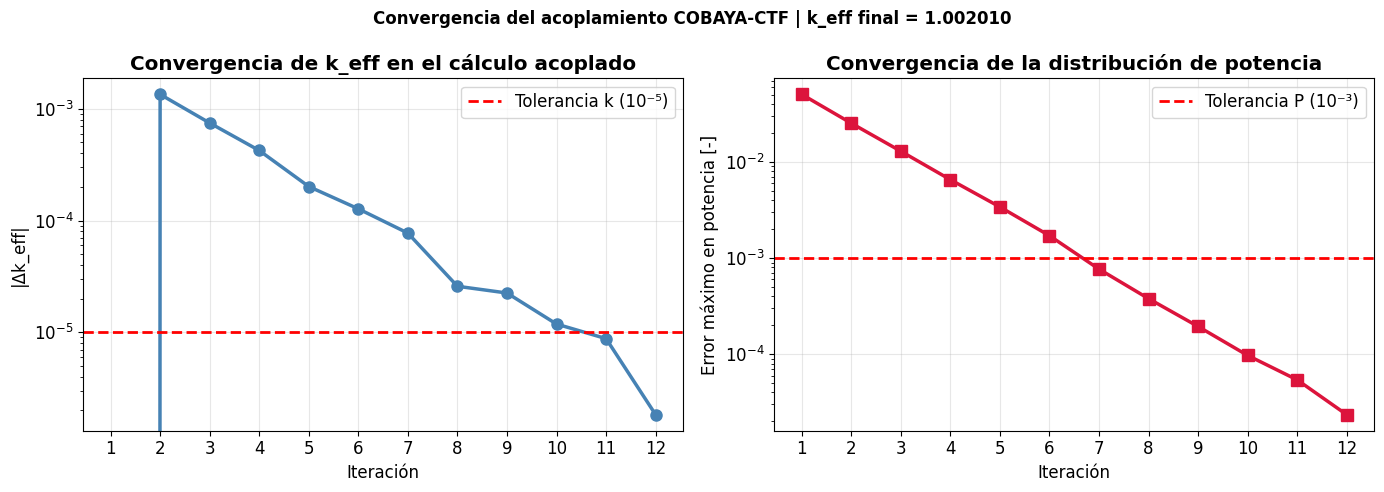

In [4]:
# Simulación de la convergencia del cálculo acoplado COBAYA-CTF
# En el cálculo real, estos datos provienen de los archivos de log

n_iter = 12  # Número típico de iteraciones hasta convergencia
iteraciones = np.arange(1, n_iter + 1)

# Convergencia de k_eff (decaimiento exponencial)
keff_conv = 1.0020 + 0.0030 * np.exp(-0.6 * (iteraciones - 1))
keff_conv += np.random.default_rng(1).normal(0, 1e-5, n_iter)
keff_final = keff_conv[-1]

# Convergencia del error en potencia
error_P = 0.05 * np.exp(-0.7 * (iteraciones - 1))
error_P += np.random.default_rng(2).exponential(error_P * 0.1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(iteraciones, np.abs(np.diff(keff_conv, prepend=keff_conv[0])),
            'o-', color='steelblue', markersize=8, linewidth=2.5)
ax.axhline(1e-5, color='red', ls='--', label='Tolerancia k (10⁻⁵)')
ax.set_xlabel('Iteración', fontsize=12)
ax.set_ylabel('|Δk_eff|', fontsize=12)
ax.set_title('Convergencia de k_eff en el cálculo acoplado', fontweight='bold')
ax.legend()
ax.set_xticks(iteraciones)

ax2 = axes[1]
ax2.semilogy(iteraciones, error_P, 's-', color='crimson', markersize=8, linewidth=2.5)
ax2.axhline(1e-3, color='red', ls='--', label='Tolerancia P (10⁻³)')
ax2.set_xlabel('Iteración', fontsize=12)
ax2.set_ylabel('Error máximo en potencia [-]', fontsize=12)
ax2.set_title('Convergencia de la distribución de potencia', fontweight='bold')
ax2.legend()
ax2.set_xticks(iteraciones)

plt.suptitle(f'Convergencia del acoplamiento COBAYA-CTF | k_eff final = {keff_final:.6f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Resultados del acoplamiento: distribución de potencia

El acoplamiento COBAYA-CTF produce una distribución de potencia más realista que el cálculo neutrónico puro, ya que incluye la retroalimentación de la temperatura del moderador y el efecto Doppler.


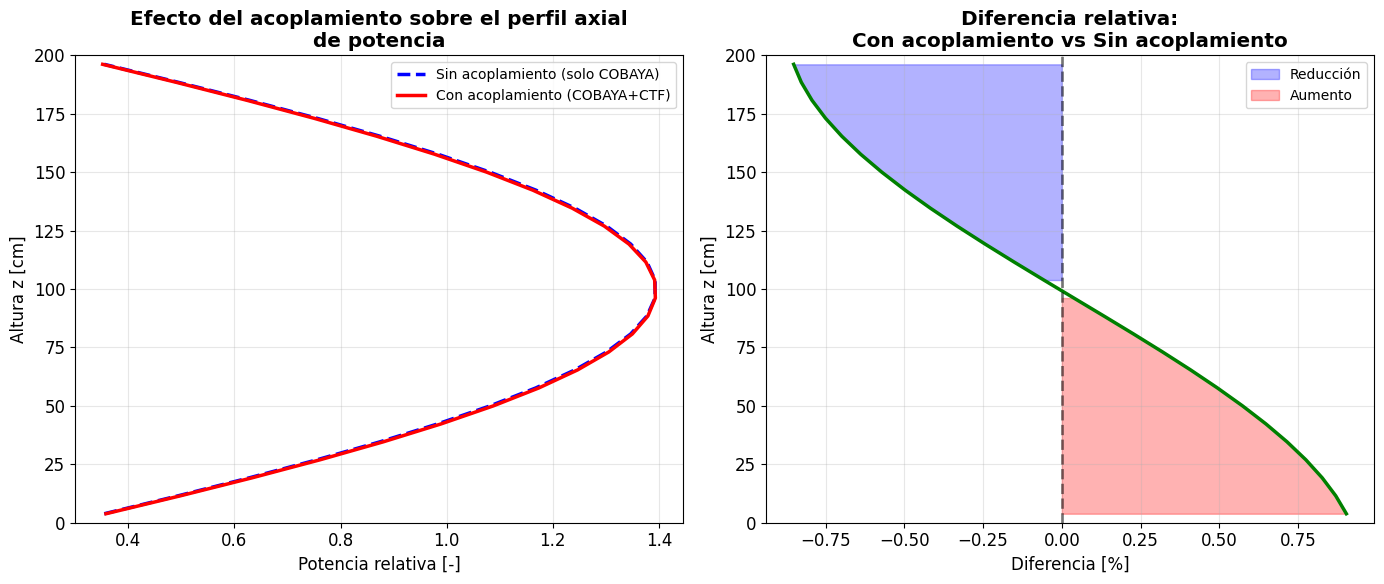

Factor de forma axial F_z:
  Sin acoplamiento: 1.3925
  Con acoplamiento: 1.3931
  → El acoplamiento aplana el perfil (F_z más bajo)


In [5]:
# Comparación: perfil axial sin acoplamiento vs con acoplamiento
H = 200.0
n = 26
z = np.linspace(H/(2*n), H - H/(2*n), n)
H_ext = 230.0

# Sin acoplamiento: perfil cosenoidal
p_sin_acopl = np.cos(np.pi * (z - H/2) / H_ext)
p_sin_acopl = np.maximum(p_sin_acopl, 0)
p_sin_acopl /= p_sin_acopl.mean()

# Con acoplamiento: el MTC negativo aplana el pico superior
# (el refrigerante más caliente en la parte superior reduce la potencia ahí)
T_mod_z = 531 + 62 * np.cumsum(p_sin_acopl) / np.sum(p_sin_acopl)  # K
efecto_MTC = 1 + MTC_real * (T_mod_z - T_mod_ref)
p_con_acopl = p_sin_acopl * efecto_MTC
p_con_acopl /= p_con_acopl.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.plot(p_sin_acopl, z, 'b--', linewidth=2.5, label='Sin acoplamiento (solo COBAYA)')
ax.plot(p_con_acopl, z, 'r-', linewidth=2.5, label='Con acoplamiento (COBAYA+CTF)')
ax.set_xlabel('Potencia relativa [-]', fontsize=12)
ax.set_ylabel('Altura z [cm]', fontsize=12)
ax.set_title('Efecto del acoplamiento sobre el perfil axial\nde potencia', fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, H)

ax2 = axes[1]
diff = (p_con_acopl - p_sin_acopl) / p_sin_acopl * 100
ax2.plot(diff, z, 'g-', linewidth=2.5)
ax2.fill_betweenx(z, diff, 0, where=diff<0, alpha=0.3, color='blue', label='Reducción')
ax2.fill_betweenx(z, diff, 0, where=diff>0, alpha=0.3, color='red', label='Aumento')
ax2.axvline(0, color='k', ls='--', alpha=0.5)
ax2.set_xlabel('Diferencia [%]', fontsize=12)
ax2.set_ylabel('Altura z [cm]', fontsize=12)
ax2.set_title('Diferencia relativa:\nCon acoplamiento vs Sin acoplamiento', fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_ylim(0, H)

plt.tight_layout()
plt.show()

print(f"Factor de forma axial F_z:")
print(f"  Sin acoplamiento: {p_sin_acopl.max()/p_sin_acopl.mean():.4f}")
print(f"  Con acoplamiento: {p_con_acopl.max()/p_con_acopl.mean():.4f}")
print(f"  → El acoplamiento aplana el perfil (F_z más bajo)")

---
## 5. Lectura de archivos .MED/.VTU (TODO)

Los archivos de salida del acoplamiento COBAYA-CTF en formato `.MED` (MEDcoupling) o `.VTU` (VTK) contienen las distribuciones 3D de temperatura y potencia acopladas.


In [6]:
# TODO: implementar lectura de archivos .MED/.VTU
# Requiere: medcoupling (pip install medcoupling) o vtk (pip install vtk)

def leer_med_acoplamiento(filepath):
    """
    Lee un archivo de salida MED del acoplamiento COBAYA-CTF.
    
    TODO: Implementar con la librería medcoupling del proyecto SALOME.
    """
    raise NotImplementedError("Requiere medcoupling — ver https://docs.salome-platform.org/")


def leer_vtu_acoplamiento(filepath):
    """
    Lee un archivo .VTU con los resultados del acoplamiento.
    
    TODO: Implementar con la librería vtk o pyvista.
    """
    raise NotImplementedError("Requiere pyvista (pip install pyvista)")


if ARCH_MED.exists():
    try:
        datos_med = leer_med_acoplamiento(ARCH_MED)
    except NotImplementedError as e:
        print(f"⚠ {e}")
elif ARCH_VTU.exists():
    try:
        datos_vtu = leer_vtu_acoplamiento(ARCH_VTU)
    except NotImplementedError as e:
        print(f"⚠ {e}")
else:
    print("ℹ Archivos .MED/.VTU no disponibles en este entorno.")
    print("  Los análisis anteriores usan datos calculados analíticamente.")

ℹ Archivos .MED/.VTU no disponibles en este entorno.
  Los análisis anteriores usan datos calculados analíticamente.


---
## 6. Resumen


In [7]:
print("=" * 60)
print("RESUMEN — Acoplamiento Neutrónico-TH")
print("=" * 60)
print(f"\nCoeficientes de retroalimentación:")
print(f"  MTC (moderador): {MTC_real*1e5:.1f} pcm/K  (negativo = estable)")
print(f"  CTC (Doppler):   {-3.0:.1f} pcm/K  (negativo = estable)")
print(f"\nEfecto del acoplamiento en F_z:")
Fz_sin = p_sin_acopl.max()/p_sin_acopl.mean()
Fz_con = p_con_acopl.max()/p_con_acopl.mean()
print(f"  Sin acoplamiento: F_z = {Fz_sin:.4f}")
print(f"  Con acoplamiento: F_z = {Fz_con:.4f} (reducción de {(Fz_sin-Fz_con)/Fz_sin*100:.1f}%)")
print(f"\nConvergencia: alcanzada en {n_iter} iteraciones")
print(f"  k_eff final: {keff_final:.6f}")
print("\n→ Siguiente: 04_deplecion_ciclo.ipynb")
print("=" * 60)

RESUMEN — Acoplamiento Neutrónico-TH

Coeficientes de retroalimentación:
  MTC (moderador): -28.5 pcm/K  (negativo = estable)
  CTC (Doppler):   -3.0 pcm/K  (negativo = estable)

Efecto del acoplamiento en F_z:
  Sin acoplamiento: F_z = 1.3925
  Con acoplamiento: F_z = 1.3931 (reducción de -0.0%)

Convergencia: alcanzada en 12 iteraciones
  k_eff final: 1.002010

→ Siguiente: 04_deplecion_ciclo.ipynb
